In [1]:
import mne
import tensorly as tl

tl.set_backend('numpy')

print(mne.get_config_path())
print(mne.get_config('MNE_DATA'))
print(mne.get_config('MOABB_RESULTS'))
print(tl.get_backend())
%pip freeze | grep moabb

/user/leuven/352/vsc35289/.mne/mne-python.json
/scratch/leuven/352/vsc35289/mne_data
/data/leuven/352/vsc35289/moabb_results
numpy
moabb==1.1.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import MotorImagery, LeftRightImagery
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

sfreq=250

paradigm=LeftRightImagery(resample=sfreq)
datasets = [
    BNCI2014_004(),
]


In [3]:
from sklearn.pipeline import Pipeline
from hoda.hoda import HODA, BTTDA,  GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper,ZScore
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold

pipelines=dict()

cv=StratifiedKFold(random_state=42, shuffle=True)


hoda_params = dict(
    max_iter=128,
    tol=1e-8,
    init ='random',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='tr',
    toeplitz=None,
    delta=None,
    extra_train_info=False,
)

bttda_params=dict(
        truncate=True,
        n_jobs=5,
        hoda_params=hoda_params,
        extra_train_info=False,
        verbose=False,
        select=True,
        cv=cv,
)

pipelines['HODA'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=1,
        **bttda_params,
    )),
    ('zscore2', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

pipelines['PARAFACDA_10'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=10,
        rank_grid=[1],
        **bttda_params,
    )),
    ('zscore2', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

pipelines['BTTDA_10'] = Pipeline([
    ('zscore1', ZScore()),
    ('bttda', GreedyBTTDA(
        max_blocks=10,
        **bttda_params,
    )),
    ('zscore2', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])

In [4]:
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from hoda.tensorize import stf_tensor

post_pipe = FunctionTransformer(stf_tensor, kw_args=dict(sfreq=sfreq, zscore=False))
results = []
for dataset in datasets:
    print(dataset.code)
    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=False,
        random_state=42,
        n_jobs=5,
        suffix=f'bttda_{dataset.code}',
    )
    results.append(evaluation.process(pipelines,postprocess_pipeline=post_pipe))
results = pd.concat(results)

BNCI2014-004


BNCI2014-004-WithinSession:   0%|          | 0/9 [00:00<?, ?it/s]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.879167,3.850553,120.0,1,0train,3,5,BNCI2014-004,HODA
1,0.606944,5.177826,120.0,1,1train,3,5,BNCI2014-004,HODA
2,0.760938,9.000816,160.0,1,2train,3,5,BNCI2014-004,HODA
3,0.892187,4.515530,160.0,1,3test,3,5,BNCI2014-004,HODA
4,0.835938,4.890276,160.0,1,4test,3,5,BNCI2014-004,HODA
...,...,...,...,...,...,...,...,...,...
130,0.784722,9.679175,120.0,9,0train,3,5,BNCI2014-004,PARAFACDA_10
131,0.509722,10.246108,120.0,9,1train,3,5,BNCI2014-004,PARAFACDA_10
132,0.816406,11.852357,160.0,9,2train,3,5,BNCI2014-004,PARAFACDA_10
133,0.909375,10.780343,160.0,9,3test,3,5,BNCI2014-004,PARAFACDA_10


In [6]:
results.to_csv('moabb_results_mi.csv')

In [8]:
results.groupby(['dataset','session', 'pipeline'])['score'].aggregate('mean') 

dataset       session  subject  pipeline    
BNCI2014-004  0train   1        BTTDA_10        0.879167
                                HODA            0.879167
                                PARAFACDA_10    0.894444
                       2        BTTDA_10        0.505556
                                HODA            0.462500
                                                  ...   
              4test    8        HODA            0.989844
                                PARAFACDA_10    0.987500
                       9        BTTDA_10        0.927344
                                HODA            0.927344
                                PARAFACDA_10    0.846875
Name: score, Length: 135, dtype: float32

In [15]:
results.groupby(['dataset','session', 'pipeline'])['score'].aggregate('std') 

dataset       session  pipeline    
BNCI2014-004  0train   BTTDA_10        0.174981
                       HODA            0.165971
                       PARAFACDA_10    0.165111
              1train   BTTDA_10        0.218253
                       HODA            0.222406
                       PARAFACDA_10    0.196294
              2train   BTTDA_10        0.186485
                       HODA            0.183544
                       PARAFACDA_10    0.156565
              3test    BTTDA_10        0.199122
                       HODA            0.181651
                       PARAFACDA_10    0.186607
              4test    BTTDA_10        0.184521
                       HODA            0.193729
                       PARAFACDA_10    0.185193
Name: score, dtype: float32

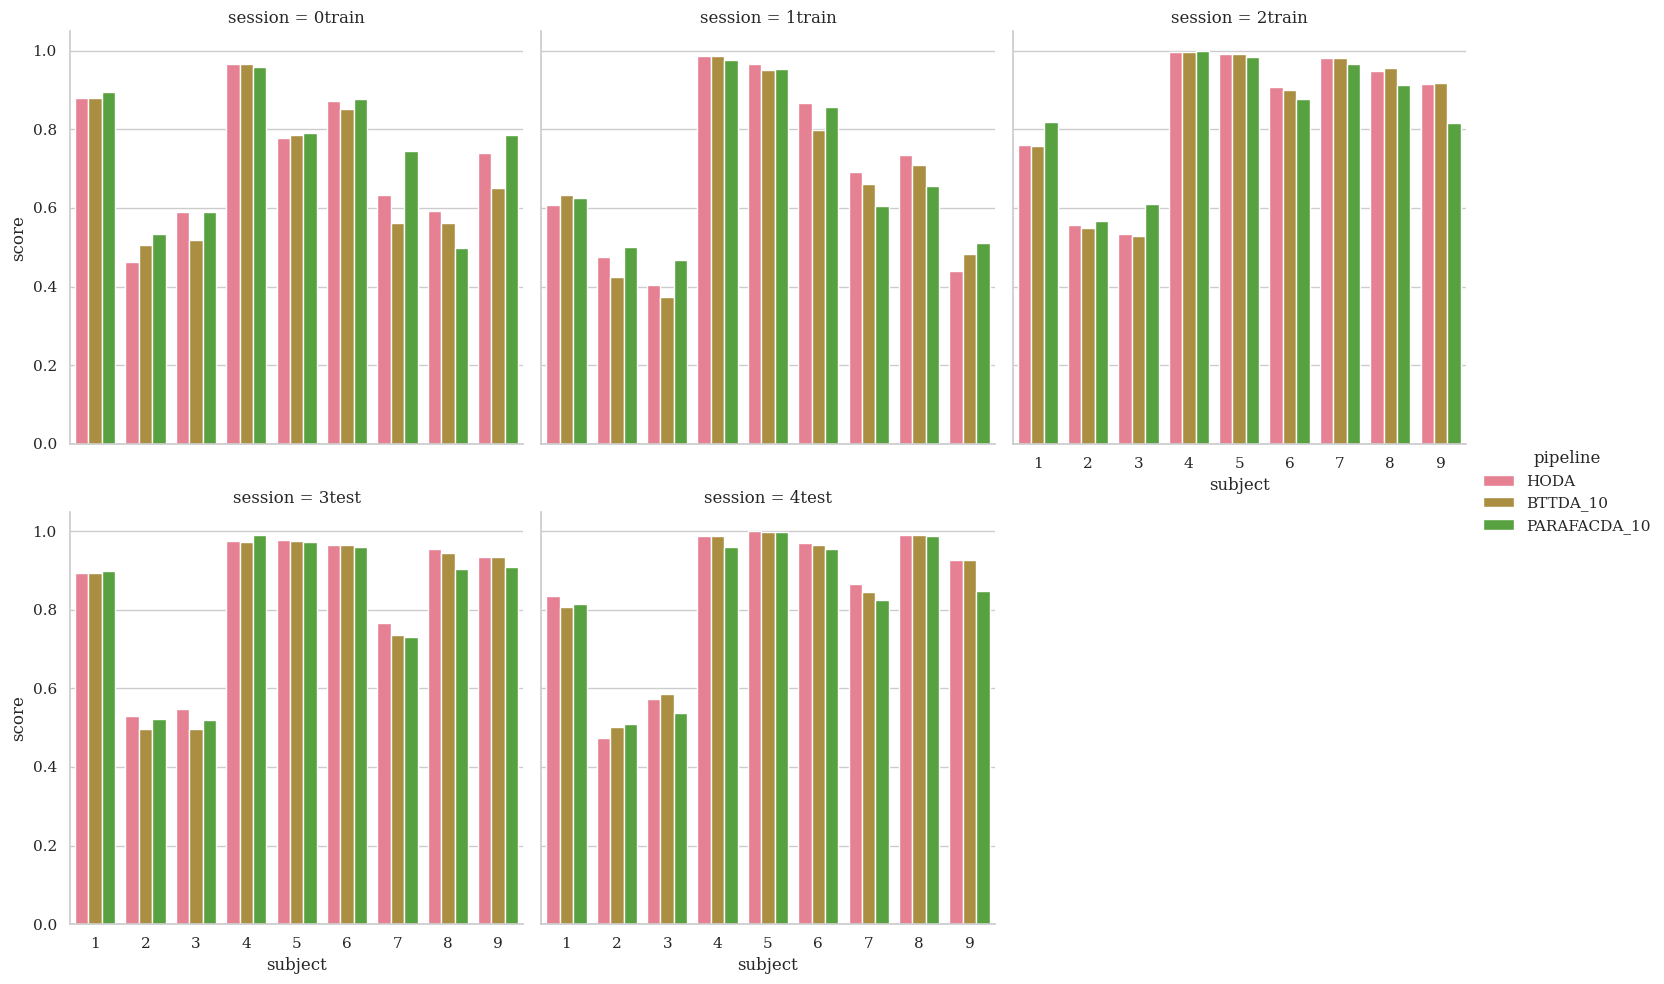

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results , col='session',x='subject', y='score',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/analysis/plotting.py:212: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.loc[row, col] = txt
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/analysis/plotting.py:212: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_df.loc[row, col] = txt
/data/leuven/352/vsc35289/miniconda3/envs/bttda/lib/python3.12/site-packages/moabb/analysis/plotting.py:212: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, ple

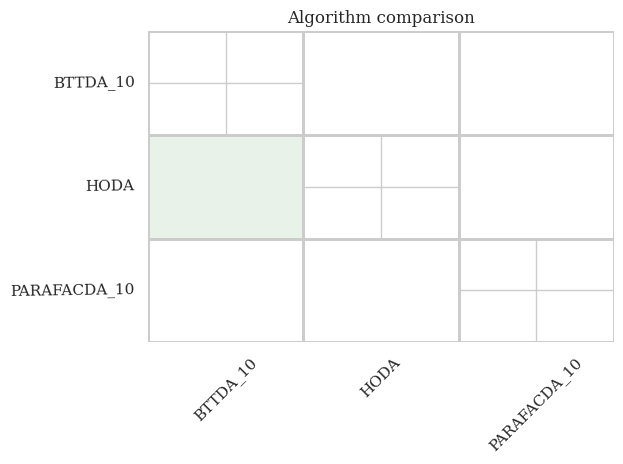

In [11]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()

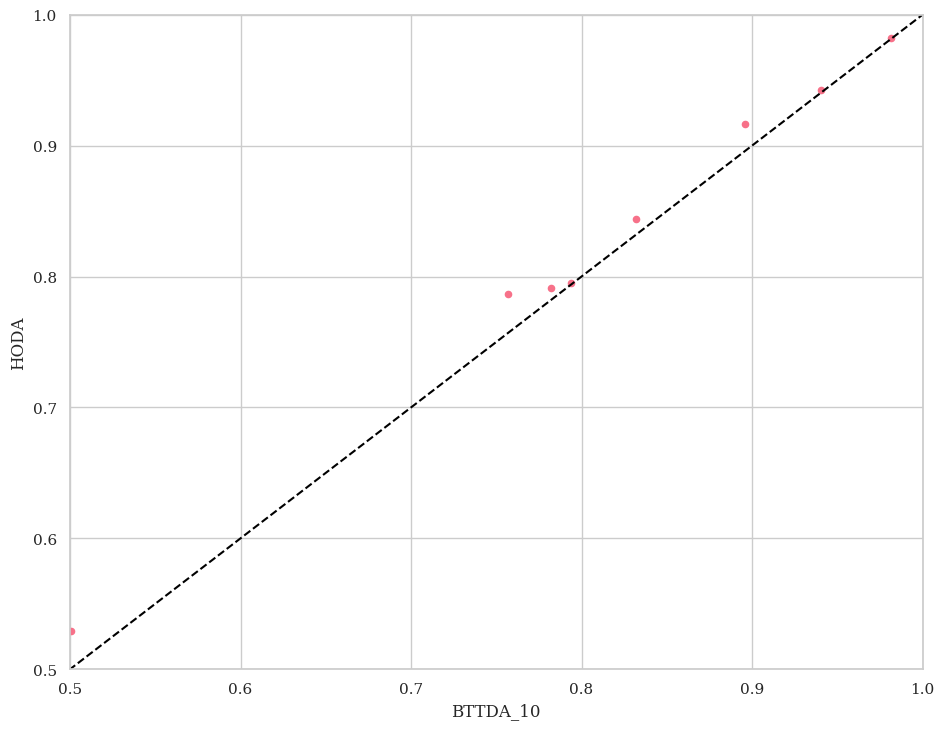

In [15]:
import moabb.analysis.plotting as moabb_plt
fig = moabb_plt.paired_plot(results, "BTTDA_10", "HODA")
plt.show()